<a href="https://colab.research.google.com/github/morenaherrera2/AA2-HerreraM-NardiG-ZorzoloJ/blob/main/C%C3%B3digo_Fuente_Herrera_Morena.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabajo Práctico Final - Visión por Computadora 2025**
*   ## ***Sistema de Detección y Clasificación de Razas de Perros***

---



### **Herrera Morena (H-1187/8)**



# Importaciones

In [1]:
!pip install faiss-cpu

import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import random
import os
import json
import seaborn as sns
import tensorflow_datasets as tfds
import faiss
import tensorflow as tf
import gradio as gr
import pickle
import numpy as np
import torch

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import Counter
from PIL import Image
from google.colab import files
from tqdm import tqdm
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras import models
from IPython import display
from IPython.display import Audio, display as ipy_display

seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 16.9 MB/s eta 0:00:00


In [2]:
# Configurar para que TensorFlow utilice la GPU por defecto
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    # Configurar para que TensorFlow asigne memoria dinámicamente
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    # Especificar la GPU por defecto
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Manejar error
    print(e)

# Carga de Datos Inicial

## Descargar data de Kaggle

In [3]:
# Cargar credenciales directamente de Kaggle
kaggle_api = {"username": "morenaherrera", "key": "9162ce4f2070bd1aeb3c55a711a983d5"}

# Crear el directorio de configuración de kaggle y guardar kaggle.json
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
  json.dump(kaggle_api, f)

# Establecer permisos y verificar conexión con Kaggle
!chmod 600 /root/.kaggle/kaggle.json
#!kaggle datasets list -s "dog breeds"

# Descargar y descomprimir el dataset
!kaggle datasets download -d gpiosenka/70-dog-breedsimage-data-set
!unzip -q 70-dog-breedsimage-data-set.zip -d ./70-dog-breeds

# Verificar estructura
dataset_path = "./70-dog-breeds"
print("cantidad de carpetas:", len(os.listdir(dataset_path)))
print("Carpetas:", os.listdir(dataset_path)[:5])

Dataset URL: https://www.kaggle.com/datasets/gpiosenka/70-dog-breedsimage-data-set
License(s): CC0-1.0
 87% 187M/215M [00:00<00:00, 200MB/s]
100% 215M/215M [00:00<00:00, 241MB/s]
cantidad de carpetas: 4
Carpetas: ['test', 'train', 'valid', 'dogs.csv']


## Train

In [4]:
# Almacenar imágenes train en un diccionario. Se guarda la ruta y etiqueta de la imagen
dicc_train = {}
train_path = "./70-dog-breeds/train"

for breed in os.listdir(train_path):
  breed_path = os.path.join(train_path, breed)
  if os.path.isdir(breed_path):
    for fname in os.listdir(breed_path):
      if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(breed_path, fname)
        dicc_train[img_path] = breed

print("Cantidad total de imágenes:", len(dicc_train))

Cantidad total de imágenes: 7946


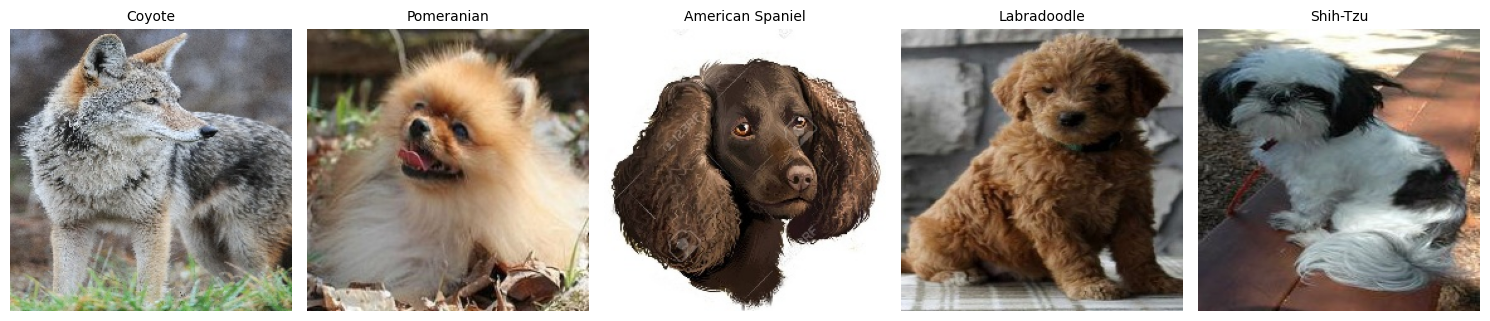

In [5]:
# Mostrar 5 imágenes aleatorias con su etiqueta
n = 5
random_items = random.sample(list(dicc_train.items()), n)
fig, axs = plt.subplots(1, n, figsize=(15, 5))
for ax, (img_path, label) in zip(axs, random_items):
  img = Image.open(img_path).convert("RGB")
  ax.imshow(img)
  ax.set_title(label, fontsize=10)
  ax.axis('off')

plt.tight_layout()
plt.show()

## Validación

In [6]:
# Almacenar imágenes valid en un diccionario
valid_path = "./70-dog-breeds/valid"
dicc_valid = {}

for breed in os.listdir(valid_path):
  breed_path = os.path.join(valid_path, breed)
  if os.path.isdir(breed_path):
    for fname in os.listdir(breed_path):
      if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(breed_path, fname)
        dicc_valid[img_path] = breed

print("Cantidad total de imágenes:", len(dicc_valid))

Cantidad total de imágenes: 700


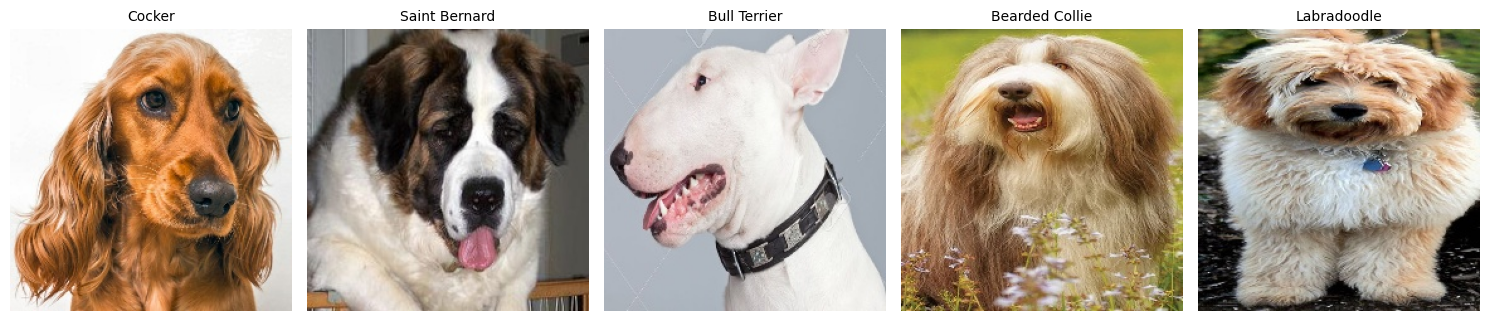

In [7]:
# Mostrar 5 imágenes aleatorias con su etiqueta
n = 5
random_items = random.sample(list(dicc_valid.items()), n)
fig, axs = plt.subplots(1, n, figsize=(15, 5))
for ax, (img_path, label) in zip(axs, random_items):
  img = Image.open(img_path).convert("RGB")
  ax.imshow(img)
  ax.set_title(label, fontsize=10)
  ax.axis('off')

plt.tight_layout()
plt.show()

## Test

In [8]:
# Almacenar imágenes test en un diccionario
test_path = "./70-dog-breeds/test"
dicc_test = {}

for breed in os.listdir(test_path):
  breed_path = os.path.join(test_path, breed)
  if os.path.isdir(breed_path):
    for fname in os.listdir(breed_path):
      if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(breed_path, fname)
        dicc_test[img_path] = breed

print("Cantidad total de imágenes:", len(dicc_test))

Cantidad total de imágenes: 700


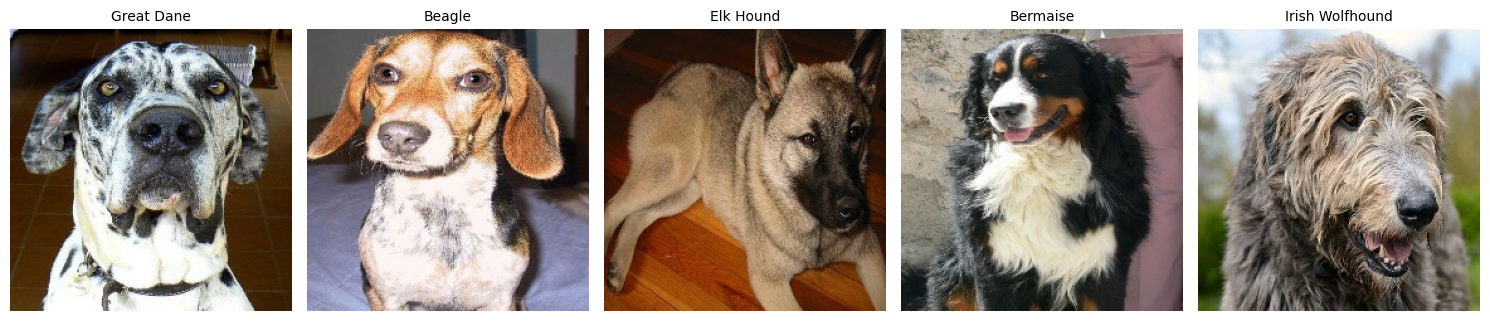

In [9]:
# Mostrar 5 imágenes aleatorias con su etiqueta
n = 5
random_items = random.sample(list(dicc_test.items()), n)
fig, axs = plt.subplots(1, n, figsize=(15, 5))
for ax, (img_path, label) in zip(axs, random_items):
  img = Image.open(img_path).convert("RGB")
  ax.imshow(img)
  ax.set_title(label, fontsize=10)
  ax.axis('off')

plt.tight_layout()
plt.show()

# ETAPA 1 - Buscador de Imágenes por Similitud

## 1. Creación de la Base de Datos Vectorial: (no ejecutar)

In [11]:
# Cargar modelo preentrenado ResNet50 (sin capa de clasificación)
model_resnet = ResNet50(weights='imagenet', include_top=False, pooling='avg')  # Output: 2048-D

# Función para obtener el embedding (vector de características) de una imagen
def get_embedding(img_path):
  img = image.load_img(img_path, target_size=(224, 224))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)
  x = preprocess_input(x)
  embedding = model_resnet.predict(x, verbose=0)
  return embedding.flatten()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


### Obtener embeddings de train

In [12]:
# Obtener la lista de rutas de imágenes y sus etiquetas desde el diccionario
image_paths_train = list(dicc_train.keys())
labels_train = list(dicc_train.values())
embeddings_train = []

print("Extrayendo embeddings del conjunto train...")

# Iterar sobre cada imagen y extraer su embedding
for img_path in tqdm(image_paths_train):
  try:
    emb = get_embedding(img_path)
    embeddings_train.append(emb)
  except:
    print(f"Error en imagen: {img_path}")
    continue

# Convertir la lista de embeddings en un arreglo NumPy
embeddings_train = np.array(embeddings_train)
print("\nEmbeddings shape:", embeddings_train.shape)

Extrayendo embeddings del conjunto train...


100%|██████████| 7946/7946 [55:55<00:00,  2.37it/s]


Embeddings shape: (7946, 2048)


In [13]:
# Guardar y descargar
np.save("embeddings_train.npy", embeddings_train)
files.download("embeddings_train.npy")

with open("image_paths_train.pkl", "wb") as f:
  pickle.dump(image_paths_train, f)
  files.download("image_paths_train.pkl")

with open("labels_train.pkl", "wb") as f:
  pickle.dump(labels_train, f)
  files.download("labels_train.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# Cargar los embeddings
embeddings_train = np.load("embeddings_train.npy")

# Cargar paths
with open("image_paths_train.pkl", "rb") as f:
  image_paths_train = pickle.load(f)

# Cargar labels
with open("labels_train.pkl", "rb") as f:
  labels_train = pickle.load(f)

embedding_img_train = {
  "embeddings": embeddings_train,
  "paths": image_paths_train,
  "labels": labels_train
}

### Crear base de datos vectorial faiss

In [15]:
# Obtener la dimensión de cada embedding
dimension = embeddings_train.shape[1] # 2048
index = faiss.IndexFlatL2(dimension) # Usa distancia euclídea L2 para comparar vectores

# Agregar los embeddings al índice FAISS
index.add(embeddings_train)

# Guardar el índice generado
faiss.write_index(index, "train.faiss")

### Obtener embeddings de validación

In [16]:
# Obtener la lista de rutas de imágenes y sus etiquetas desde el diccionario
image_paths_valid = list(dicc_valid.keys())
labels_valid = list(dicc_valid.values())
embeddings_valid = []

print("Extrayendo embeddings del conjunto train...")

# Iterar sobre cada imagen y extraer su embedding
for img_path in tqdm(image_paths_valid):
  try:
    emb = get_embedding(img_path)
    embeddings_valid.append(emb)
  except:
    print(f"Error en imagen: {img_path}")
    continue

# Convertir la lista de embeddings en un arreglo NumPy
embeddings_valid = np.array(embeddings_valid)
print("\nEmbeddings shape:", embeddings_valid.shape)

Extrayendo embeddings del conjunto train...


100%|██████████| 700/700 [04:44<00:00,  2.46it/s]


Embeddings shape: (700, 2048)


In [17]:
# Guardar y descargar
np.save("embeddings_valid.npy", embeddings_valid)
files.download("embeddings_valid.npy")

with open("image_paths_valid.pkl", "wb") as f:
  pickle.dump(image_paths_valid, f)
  files.download("image_paths_valid.pkl")

with open("labels_valid.pkl", "wb") as f:
  pickle.dump(labels_valid, f)
  files.download("labels_valid.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# Cargar los embeddings
embeddings_valid = np.load("embeddings_valid.npy")

# Cargar paths
with open("image_paths_valid.pkl", "rb") as f:
  image_paths_valid = pickle.load(f)

# Cargar labels
with open("labels_valid.pkl", "rb") as f:
  labels_valid = pickle.load(f)

embedding_img_valid = {
  "embeddings": embeddings_valid,
  "paths": image_paths_valid,
  "labels": labels_valid
}

## 1.1 - ejecutar

In [28]:
!gdown "1FVsCBFSw71i_4LXo9G3A2hG15MHEwnFG" --output "train.faiss"
!gdown "1yAaP2fJTSXSSoIMibEjg8gSzdzB8xKaF" --output "labels_valid.pkl"
!gdown "1JbJkvZ2YNVpShmEbBBFjRsNfo-jMyMEI" --output "labels_train.pkl"
!gdown "1170faOqJoq8uaZPsbM8JsrP9cewXwSle" --output "image_paths_valid.pkl"
!gdown "1HlVgnkWEXsBdo7XeANPTMOExI1AObkq9" --output "image_paths_train.pkl"
!gdown "1OcpB-B1jiCQZg43ohFM-u-T6piAbzLnD" --output "embeddings_valid.npy"
!gdown "1k8XThDt4Zj4y4ffGa1R-PP9cm7gQdDvw" --output "embeddings_train.npy"

Downloading...
From: https://drive.google.com/uc?id=1FVsCBFSw71i_4LXo9G3A2hG15MHEwnFG
To: /content/train.faiss
100% 65.1M/65.1M [00:00<00:00, 120MB/s]
Downloading...
From: https://drive.google.com/uc?id=1yAaP2fJTSXSSoIMibEjg8gSzdzB8xKaF
To: /content/labels_valid.pkl
100% 2.15k/2.15k [00:00<00:00, 5.92MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JbJkvZ2YNVpShmEbBBFjRsNfo-jMyMEI
To: /content/labels_train.pkl
100% 16.7k/16.7k [00:00<00:00, 33.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1170faOqJoq8uaZPsbM8JsrP9cewXwSle
To: /content/image_paths_valid.pkl
100% 29.0k/29.0k [00:00<00:00, 28.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1HlVgnkWEXsBdo7XeANPTMOExI1AObkq9
To: /content/image_paths_train.pkl
100% 334k/334k [00:00<00:00, 6.78MB/s]
Downloading...
From: https://drive.google.com/uc?id=1OcpB-B1jiCQZg43ohFM-u-T6piAbzLnD
To: /content/embeddings_valid.npy
100% 5.73M/5.73M [00:00<00:00, 30.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=

In [29]:
# Cargar el índice FAISS
index = faiss.read_index("train.faiss")

# Cargar los labels
with open("labels_train.pkl", "rb") as f:
  labels_train = pickle.load(f)

with open("labels_valid.pkl", "rb") as f:
  labels_valid = pickle.load(f)

# Cargar las rutas de imágenes
with open("image_paths_train.pkl", "rb") as f:
  image_paths_train = pickle.load(f)

with open("image_paths_valid.pkl", "rb") as f:
  image_paths_valid = pickle.load(f)

# Cargar los embeddings
embeddings_train = np.load("embeddings_train.npy")
embeddings_valid = np.load("embeddings_valid.npy")

In [30]:
embedding_img_train = {
  "embeddings": embeddings_train,
  "paths": image_paths_train,
  "labels": labels_train
}

In [31]:
embedding_img_valid = {
  "embeddings": embeddings_valid,
  "paths": image_paths_valid,
  "labels": labels_valid
}

## 2. Desarrollo de la Aplicación en Gradio:

In [33]:
# Cargar modelo preentrenado ResNet50 (sin capa de clasificación)
model_resnet = ResNet50(weights='imagenet', include_top=False, pooling='avg')  # Output: 2048-D

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [34]:
# Cargar índice FAISS
index = faiss.read_index("train.faiss")

def get_embedding_from_image(img):
  x = image.img_to_array(img.resize((224, 224)))
  x = np.expand_dims(x, axis=0)
  x = preprocess_input(x)
  embedding = model_resnet.predict(x, verbose=0)
  return embedding.flatten()

# Función para encontrar las 10 imágenes más similares. predecir_raza=True si se quiere predecir la raza
def buscar_similares(input_img, predecir_raza=False):
  # Obtener el embedding de la imagen cargada
  query_vector = get_embedding_from_image(input_img).reshape(1, -1)

  # Buscar en el índice las 10 imágenes más cercanas
  D, I = index.search(query_vector, 10)  # I: índices, D: distancias
  similares = [Image.open(image_paths_train[i]).convert("RGB") for i in I[0]]

  # Si predicción=True, usar voto mayoritario sobre las etiquetas
  if predecir_raza:
    raza_predicha = predecir_raza_por_voto(I[0], labels_train)
    return similares, raza_predicha
  else:
    return similares

In [35]:
# Interfaz en Gradio
gr.Interface(
  fn=buscar_similares,
  inputs=gr.Image(type="pil", label="Subí una imagen de un perro"),
  outputs=[gr.Gallery(label="Imágenes más similares", columns=5)],
  title="Buscador de razas de perro por similitud",
  description="Esta app busca las 10 imágenes más parecidas a la que subas"
).launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://046c98821dbf5a0c3f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 3. Clasificación Basada en Similitud y Métrica de Evaluación:

In [36]:
from collections import Counter
# Función para predecir la raza usando voto mayoritario
def predecir_raza_por_voto(indices_similares, labels):
    try:
        razas = [labels[i] for i in indices_similares if i < len(labels)]
        if not razas:
            return "No se pudo predecir"
        voto = Counter(razas).most_common(1)[0][0]
        return voto
    except Exception as e:
        print("❌ Error en predecir_raza_por_voto:", e)
        return "Error: " + str(e)

# Interfaz en Gradio
gr.Interface(
  fn=lambda img: buscar_similares(img, predecir_raza=True),
  inputs=gr.Image(type="pil", label="Subí una imagen de un perro"),
  outputs=[
    gr.Gallery(label="Imágenes más similares", columns=5),
    gr.Textbox(label="Raza predicha por voto mayoritario")
    ],
  title="Clasificador de razas de perro por similitud",
  description="Esta app busca las 10 imágenes más parecidas a la que subas y predice la raza según voto mayoritario."
).launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c3f1decb8b4b4d4c73.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [37]:
# Funciones NDCG@10
def dcg(relevancias):
  return np.sum([
    (2 ** rel - 1) / np.log2(idx + 2)
    for idx, rel in enumerate(relevancias)
  ])

def ndcg_at_k(true_label, predicted_labels, k=10):
  relevancias = [1 if label == true_label else 0 for label in predicted_labels[:k]]
  ideal = sorted(relevancias, reverse=True)
  dcg_val = dcg(relevancias)
  idcg_val = dcg(ideal)
  return dcg_val / idcg_val if idcg_val != 0 else 0.0

# Evaluación usando embeddings precalculados
ndcgs = []

for emb, true_label in tqdm(zip(embedding_img_valid["embeddings"], embedding_img_valid["labels"]), total=len(embedding_img_valid["embeddings"])):
  # Búsqueda en el índice con el embedding de validación
  _, I = index.search(emb.reshape(1, -1), 10)

  # Obtener las etiquetas predichas del set de entrenamiento
  pred_labels = [labels_train[i] for i in I[0]]

  # Calcular NDCG@10
  ndcg = ndcg_at_k(true_label, pred_labels, k=10)
  ndcgs.append(ndcg)

print(f"\nNDCG@10 promedio en validación: {np.mean(ndcgs):.4f}")

100%|██████████| 700/700 [00:06<00:00, 113.05it/s]


NDCG@10 promedio en validación: 0.9351


# ETAPA 2 - Entrenamiento y Comparación de Modelos de Clasificación

## 1. Entrenamiento de Modelos:

### Preparación y Análisis Exploratorio de Datos (EDA)

In [39]:
# Normalizar y redimensionar a 224x224 (compatible con ResNet)
transform = transforms.Compose([
  transforms.Resize((224, 224)),
  transforms.ToTensor(),  # Convierte a rango [0,1]
  transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset de entrenamiento
train_dir = "./70-dog-breeds/train"
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)

# Dataset de validación
valid_dir = "./70-dog-breeds/valid"
valid_dataset = datasets.ImageFolder(valid_dir, transform=transform)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2)

# Dataset de testeo
test_dir = "./70-dog-breeds/test"
test_dataset = datasets.ImageFolder(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Número de clases
num_classes = len(train_dataset.classes)

Total de clases: 70


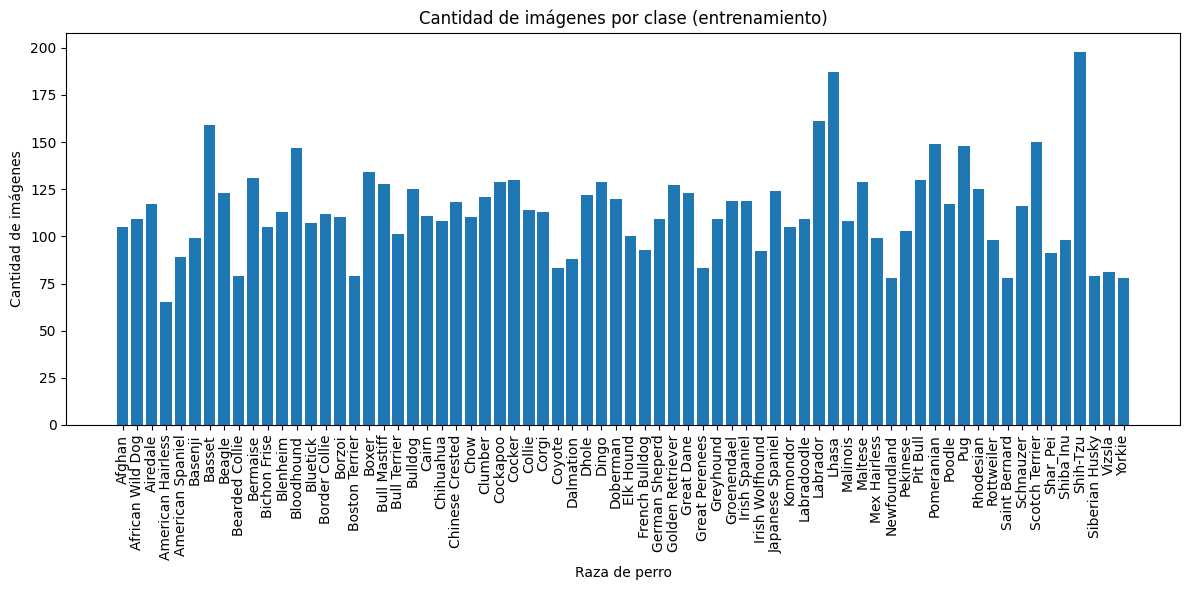

In [53]:
import matplotlib.pyplot as plt
from collections import Counter

# Obtener las clases y sus índices
class_names = train_dataset.classes
class_counts = Counter([label for _, label in train_dataset])

# Visualización
plt.figure(figsize=(12, 6))
plt.bar(class_names, [class_counts[i] for i in range(len(class_names))])
plt.xticks(rotation=90)
plt.title("Cantidad de imágenes por clase (entrenamiento)")
plt.xlabel("Raza de perro")
plt.ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.show()

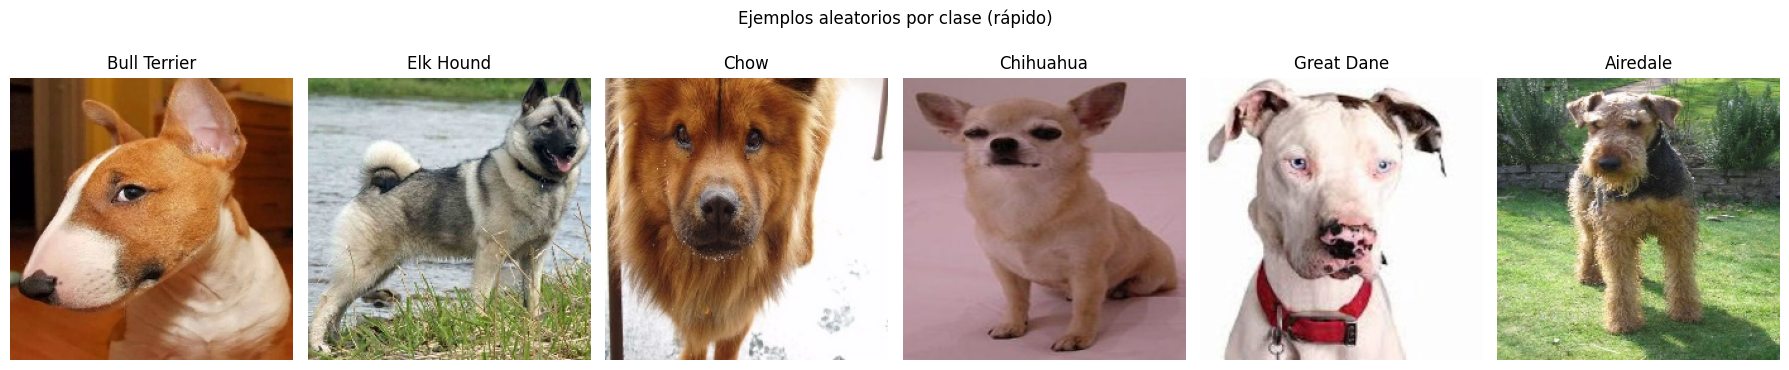

In [61]:
def build_indices_por_clase(dataset):
    indices_por_clase = {}
    for idx, (_, label) in enumerate(dataset):
        indices_por_clase.setdefault(label, []).append(idx)
    return indices_por_clase

def mostrar_ejemplos_aleatorios(dataset, class_names, indices_por_clase, num_clases=6):
    fig, axes = plt.subplots(1, num_clases, figsize=(18, 4))
    clases_aleatorias = random.sample(list(indices_por_clase.keys()), num_clases)

    for i, clase in enumerate(clases_aleatorias):
        idx = random.choice(indices_por_clase[clase])
        img, label = dataset[idx]
        img = img.permute(1, 2, 0).numpy()
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        axes[i].imshow(img.clip(0, 1))
        axes[i].set_title(class_names[label])
        axes[i].axis("off")

    plt.suptitle("Ejemplos aleatorios por clase")
    plt.tight_layout()
    plt.show()

# Solo lo hacés una vez
indices_por_clase = build_indices_por_clase(train_dataset)

# Y luego esto es casi instantáneo
mostrar_ejemplos_aleatorios(train_dataset, class_names, indices_por_clase)

In [58]:
img, label = train_dataset[0]
print(f"Forma de la imagen: {img.shape}")
print(f"Tipo de dato: {img.dtype}")
print(f"Clase: {class_names[label]}")

Forma de la imagen: torch.Size([3, 224, 224])
Tipo de dato: torch.float32
Clase: Afghan


In [59]:
print(f"Train: {len(train_dataset)} imágenes")
print(f"Valid: {len(valid_dataset)} imágenes")
print(f"Test: {len(test_dataset)} imágenes")


Train: 7946 imágenes
Valid: 700 imágenes
Test: 700 imágenes


### Modelo A (Transfer Learning)

In [41]:
import torch.nn as nn
from torchvision.models import resnet18

# Modelo ResNet18 preentrenado
modelo_resnet18 = resnet18(pretrained=True)

# Congelar todas las capas excepto la última
for param in modelo_resnet18.parameters():
  param.requires_grad = False

# Reemplazar la capa de clasificación
modelo_resnet18.fc = nn.Linear(modelo_resnet18.fc.in_features, num_classes)

# Solo entrenar la última capa
optimizer = torch.optim.Adam(modelo_resnet18.fc.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Mover a GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo_resnet18 = modelo_resnet18.to(device)

In [45]:
import time
from tqdm import tqdm
import copy

def entrenar_resnet18(model, train_loader, valid_loader, criterion, optimizer, num_epochs=20, patience=5):
    historia = {
        "train_loss": [],
        "train_accuracy": [],
        "valid_loss": [],
        "valid_accuracy": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    early_stopping_counter = 0

    for epoch in range(num_epochs):
        print(f"\n🔁 Época {epoch+1}/{num_epochs}", flush=True)

        # --- Entrenamiento ---
        model.train()
        total_loss, total_correct = 0, 0
        for images, labels in tqdm(train_loader, desc="Entrenando", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()

        train_loss = total_loss / len(train_loader.dataset)
        train_acc = total_correct / len(train_loader.dataset)

        # --- Validación ---
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        valid_loss = val_loss / len(valid_loader.dataset)
        valid_acc = val_correct / len(valid_loader.dataset)

        # Guardar métricas
        historia["train_loss"].append(train_loss)
        historia["train_accuracy"].append(train_acc)
        historia["valid_loss"].append(valid_loss)
        historia["valid_accuracy"].append(valid_acc)

        # Mostrar resultados
        print(f"📊 Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Train Acc = {train_acc:.4f} | Valid Loss = {valid_loss:.4f}, Valid Acc = {valid_acc:.4f}", flush=True)

        # Early Stopping
        if valid_acc > best_acc:
            best_acc = valid_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1
            if early_stopping_counter >= patience:
                print("⏹️ Early stopping triggered.")
                break

    # Restaurar el mejor modelo
    model.load_state_dict(best_model_wts)
    return model, historia

entrenar_resnet18(modelo_resnet18, train_loader, valid_loader, criterion, optimizer, num_epochs=10)


🔁 Época 1/10


📊 Epoch 1: Train Loss = 0.7242, Train Acc = 0.8394 | Valid Loss = 0.6264, Valid Acc = 0.8914

🔁 Época 2/10


📊 Epoch 2: Train Loss = 0.4782, Train Acc = 0.8784 | Valid Loss = 0.5711, Valid Acc = 0.9014

🔁 Época 3/10


📊 Epoch 3: Train Loss = 0.3845, Train Acc = 0.8973 | Valid Loss = 0.5565, Valid Acc = 0.9057

🔁 Época 4/10


📊 Epoch 4: Train Loss = 0.3269, Train Acc = 0.9132 | Valid Loss = 0.5654, Valid Acc = 0.9029

🔁 Época 5/10


...

📊 Epoch 7: Train Loss = 0.2263, Train Acc = 0.9372 | Valid Loss = 0.5752, Valid Acc = 0.9157

🔁 Época 8/10


📊 Epoch 8: Train Loss = 0.2080, Train Acc = 0.9421 | Valid Loss = 0.5909, Valid Acc = 0.9143

🔁 Época 9/10


📊 Epoch 9: Train Loss = 0.1864, Train Acc = 0.9508 | Valid Loss = 0.5891, Valid Acc = 0.9086

🔁 Época 10/10


📊 Epoch 10: Train Loss = 0.1860, Train Acc = 0.9493 | Valid Loss = 0.6273, Valid Acc = 0.9157
⏹️ Early stopping triggered.


(ResNet(
   (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
   (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (relu): ReLU(inplace=True)
   (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
   (layer1): Sequential(
     (0): BasicBlock(
       (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU(inplace=True)
       (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     )
     (1): BasicBlock(
       (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU

In [47]:
from sklearn.metrics import classification_report
def mostrar_metricas_generales(model, loader, clases):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    print(classification_report(y_true, y_pred, target_names=clases))

mostrar_metricas_generales(modelo_resnet18, valid_loader, train_dataset.classes)

                   precision    recall  f1-score   support

           Afghan       1.00      1.00      1.00        10
 African Wild Dog       1.00      1.00      1.00        10
         Airedale       1.00      0.90      0.95        10
American Hairless       0.00      0.00      0.00        10
 American Spaniel       0.00      0.00      0.00        10
          Basenji       0.77      1.00      0.87        10
           Basset       0.89      0.80      0.84        10
           Beagle       0.82      0.90      0.86        10
   Bearded Collie       0.90      0.90      0.90        10
         Bermaise       1.00      1.00      1.00        10
     Bichon Frise       1.00      1.00      1.00        10
         Blenheim       1.00      1.00      1.00        10
       Bloodhound       0.91      1.00      0.95        10
         Bluetick       1.00      1.00      1.00        10
    Border Collie       1.00      1.00      1.00        10
           Borzoi       0.91      1.00      0.95       

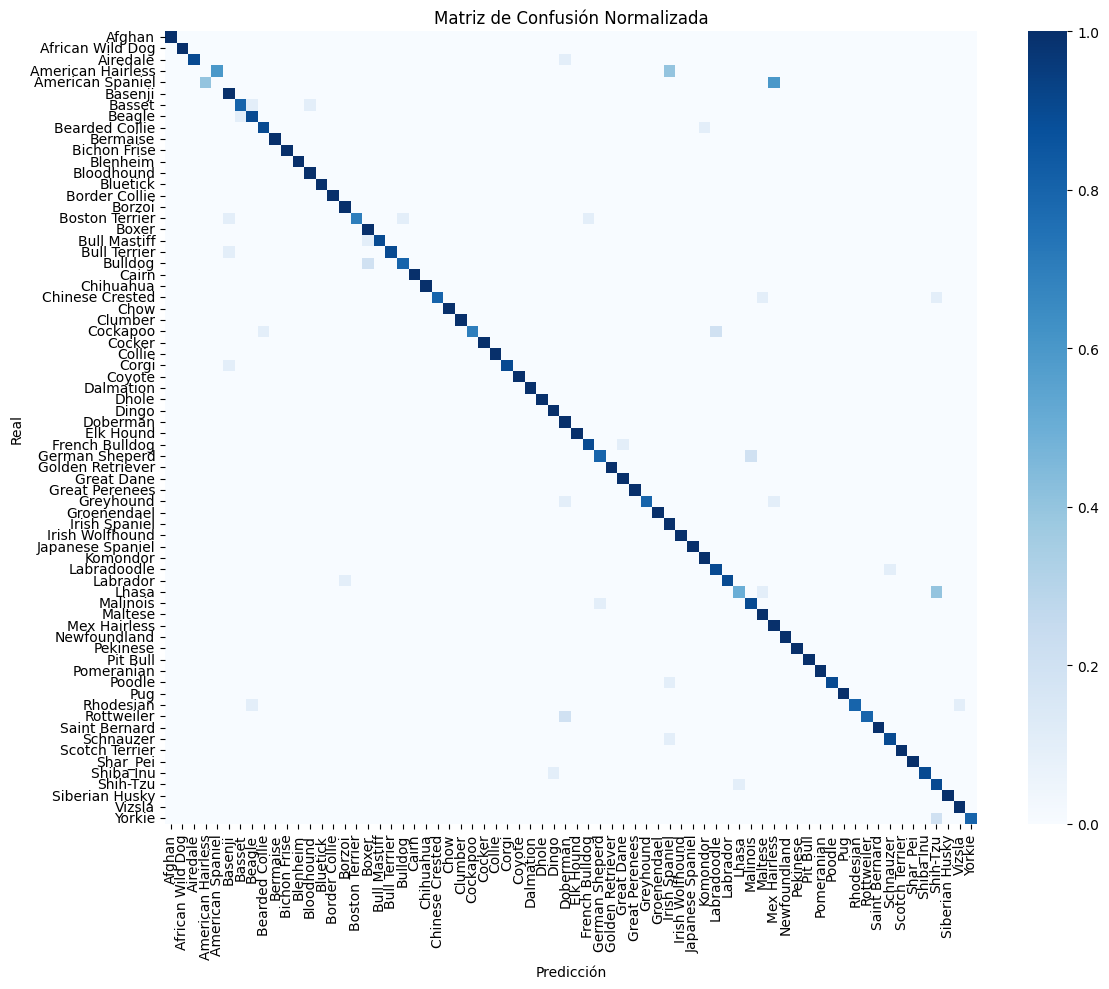

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
def mostrar_matriz_confusion(model, loader, clases, normalize=True):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    cm = confusion_matrix(y_true, y_pred, normalize='true' if normalize else None)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=clases, yticklabels=clases)
    plt.title("Matriz de Confusión" + (" Normalizada" if normalize else ""))
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

mostrar_matriz_confusion(modelo_resnet18, valid_loader, train_dataset.classes)

In [ ]:
def graficar_historia_completa(historia):
    epochs = range(1, len(historia["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, historia["train_loss"], label="Train Loss", marker='o')
    plt.plot(epochs, historia["valid_loss"], label="Valid Loss", marker='o')
    plt.title("Pérdida por época")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, historia["train_accuracy"], label="Train Accuracy", marker='o')
    plt.plot(epochs, historia["valid_accuracy"], label="Valid Accuracy", marker='o')
    plt.title("Exactitud por época")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

graficar_historia_completa(historia)

In [51]:
# Guardar modelo entrenado
torch.save(modelo_resnet18.state_dict(), "modelo_resnet18.pth")
from google.colab import files
files.download("modelo_resnet18.pth")

"""# Guardar historia (loss y accuracy por época)
with open("historia_resnet18.pkl", "wb") as f:
  pickle.dump(historia, f)
files.download("historia_resnet18.pkl")"""

# Reconstruir la arquitectura
from torchvision.models import resnet18

modelo_resnet18 = resnet18(pretrained=True)
modelo_resnet18.fc = nn.Linear(modelo_resnet18.fc.in_features, num_classes)

# Cargar los pesos guardados
modelo_resnet18.load_state_dict(torch.load("modelo_resnet18.pth"))
modelo_resnet18.to(device)
modelo_resnet18.eval()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Modelo B (Opcional, recomendado)

## 2. Integración y Selección en la Aplicación:

# ETAPA 3 - Pipeline de Detección y Clasificación en Escenas Complejas

## 1. Detección de Objetos:

In [ ]:
!pip install ultralytics


image 1/1 /content/ejemplo_para_yolo6.jpg: 448x640 1 cat, 1 dog, 375.1ms
Speed: 4.1ms preprocess, 375.1ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)


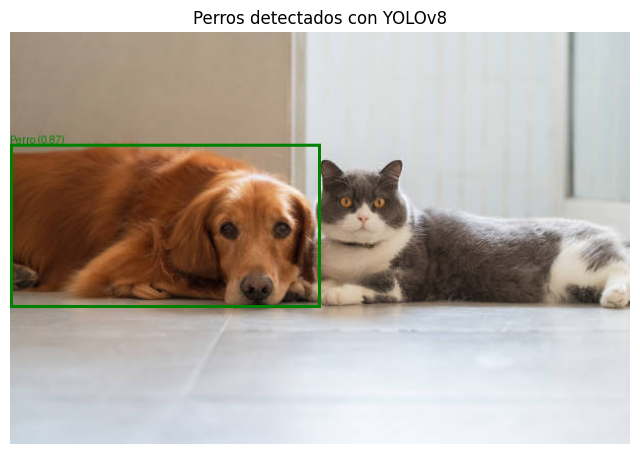

In [ ]:
from ultralytics import YOLO
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# ---------- 1. Cargar el modelo YOLO ----------
model = YOLO('yolov8n.pt')

# ---------- 2. Ruta a la imagen ----------
#image_path = "/content/70-dog-breeds/test/Beagle/01.jpg"
#image_path = "/content/ejemplo_para_yolo1.jpg"
#image_path = "/content/ejemplo_para_yolo5.jpg"
#image_path = "/content/ejemplo_para_yolo7.jpg"
image_path = "/content/ejemplo_para_yolo6.jpg"

# ---------- 3. Hacer predicción ----------
results = model(image_path)
boxes = results[0].boxes

# ---------- 4. Cargar imagen y preparar para dibujar ----------
image = Image.open(image_path).convert("RGB")
image_draw = image.copy()
draw = ImageDraw.Draw(image_draw)

# Tipografía (opcional)
try:
    font = ImageFont.truetype("arial.ttf", 20)
except:
    font = ImageFont.load_default()

# ---------- 5. Dibujar cajas para clase "dog" (16 en COCO) ----------
for box in boxes:
    class_id = int(box.cls)
    conf = float(box.conf)
    if class_id == 16:  # Clase "dog"
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        draw.rectangle([x1, y1, x2, y2], outline="green", width=3)
        draw.text((x1, y1 - 10), f"Perro ({conf:.2f})", fill="green", font=font)

# ---------- 6. Mostrar resultado ----------
plt.figure(figsize=(8, 8))
plt.imshow(image_draw)
plt.axis("off")
plt.title("Perros detectados con YOLOv8")
plt.show()

## 2. Creación del Pipeline Completo:

In [ ]:
import os
import shutil
from PIL import Image, ImageDraw
from ultralytics import YOLO
import gradio as gr

# ---------- Configuración YOLO ----------
model = YOLO('yolov8n.pt')
recortes_dir = "recortes"

def detectar_perros(imagen):
    # Limpiar carpeta de recortes
    if os.path.exists(recortes_dir):
        shutil.rmtree(recortes_dir)
    os.makedirs(recortes_dir)

    # Guardar copia original
    imagen_rgb = imagen.convert("RGB")
    image_draw = imagen_rgb.copy()
    draw = ImageDraw.Draw(image_draw)

    # Detección con YOLO
    results = model(imagen_rgb)
    boxes = results[0].boxes
    dog_boxes = [box for box in boxes if int(box.cls) == 16]

    recortes = []
    for i, box in enumerate(dog_boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        crop = imagen_rgb.crop((x1, y1, x2, y2))
        crop_path = os.path.join(recortes_dir, f"perro_{i+1}.jpg")
        crop.save(crop_path)
        recortes.append(crop)

        # Dibujar caja en la imagen original
        draw.rectangle([x1, y1, x2, y2], outline="green", width=3)

    return image_draw, recortes

# ---------- Interfaz Gradio ----------
gr.Interface(
    fn=detectar_perros,
    inputs=gr.Image(type="pil", label="Subí una imagen"),
    outputs=[
        gr.Image(type="pil", label="Imagen con perros detectados"),
        gr.Gallery(label="Recortes de perros detectados")
    ],
    title="Detector de Perros con YOLOv8",
    description="Subí una imagen del mundo real y el sistema detectará los perros y mostrará sus recortes."
).launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0100f9b159aa4866c2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# ETAPA 4 - Evaluación, Optimización y Herramientas de Anotación

In [ ]:
imagenes_etapa4 = "imagenes_etapa4"
if os.path.exists(imagenes_etapa4):
    shutil.rmtree(imagenes_etapa4)
os.makedirs(imagenes_etapa4)

In [ ]:
import os

# Ruta a la carpeta 'train' (ajustá si es necesario)
train_dir = "/content/70-dog-breeds/train"

# Listar todas las subcarpetas
razas = sorted([
    nombre for nombre in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, nombre))
])

# Mostrar la lista
for i, raza in enumerate(razas):
    print(f"{i}: {raza}")

0: Afghan
1: African Wild Dog
2: Airedale
3: American Hairless
4: American Spaniel
5: Basenji
6: Basset
7: Beagle
8: Bearded Collie
9: Bermaise
10: Bichon Frise
11: Blenheim
12: Bloodhound
13: Bluetick
14: Border Collie
15: Borzoi
16: Boston Terrier
17: Boxer
18: Bull Mastiff
19: Bull Terrier
20: Bulldog
21: Cairn
22: Chihuahua
23: Chinese Crested
24: Chow
25: Clumber
26: Cockapoo
27: Cocker
28: Collie
29: Corgi
30: Coyote
31: Dalmation
32: Dhole
33: Dingo
34: Doberman
35: Elk Hound
36: French Bulldog
37: German Sheperd
38: Golden Retriever
39: Great Dane
40: Great Perenees
41: Greyhound
42: Groenendael
43: Irish Spaniel
44: Irish Wolfhound
45: Japanese Spaniel
46: Komondor
47: Labradoodle
48: Labrador
49: Lhasa
50: Malinois
51: Maltese
52: Mex Hairless
53: Newfoundland
54: Pekinese
55: Pit Bull
56: Pomeranian
57: Poodle
58: Pug
59: Rhodesian
60: Rottweiler
61: Saint Bernard
62: Schnauzer
63: Scotch Terrier
64: Shar_Pei
65: Shiba Inu
66: Shih-Tzu
67: Siberian Husky
68: Vizsla
69: Yorki

In [ ]:
import os
import shutil
import json

# Ruta de salida
output_dir = "anotaciones"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

# Lista de razas (index = ID)
razas_70 = [
    "Afghan", "African Wild Dog", "Airedale", "American Hairless", "American Spaniel", "Basenji", "Basset", "Beagle",
    "Bearded Collie", "Bermaise", "Bichon Frise", "Blenheim", "Bloodhound", "Bluetick", "Border Collie", "Borzoi",
    "Boston Terrier", "Boxer", "Bull Mastiff", "Bull Terrier", "Bulldog", "Cairn", "Chihuahua", "Chinese Crested",
    "Chow", "Clumber", "Cockapoo", "Cocker", "Collie", "Corgi", "Coyote", "Dalmation", "Dhole", "Dingo", "Doberman",
    "Elk Hound", "French Bulldog", "German Sheperd", "Golden Retriever", "Great Dane", "Great Perenees", "Greyhound",
    "Groenendael", "Irish Spaniel", "Irish Wolfhound", "Japanese Spaniel", "Komondor", "Labradoodle", "Labrador",
    "Lhasa", "Malinois", "Maltese", "Mex Hairless", "Newfoundland", "Pekinese", "Pit Bull", "Pomeranian", "Poodle",
    "Pug", "Rhodesian", "Rottweiler", "Saint Bernard", "Schnauzer", "Scotch Terrier", "Shar_Pei", "Shiba Inu",
    "Shih-Tzu", "Siberian Husky", "Vizsla", "Yorkie"
]

# Anotaciones manuales
anotaciones_datos = {
    "ejemplo_para_yolo2.jpg": [([120, 180, 430, 600], 37)],
    "ejemplo_para_yolo3.jpg": [([200, 150, 600, 650], 61)],
    "ejemplo_para_yolo5.jpg": [([70, 240, 240, 520], 65), ([320, 180, 540, 540], 37)],
    "ejemplo_para_yolo6.jpg": [([180, 220, 550, 610], 38)],
    "ejemplo_para_yolo7.jpg": [([110, 240, 290, 540], 67), ([360, 250, 530, 530], 67)],
    "ejemplo_para_yolo8.jpg": [([230, 260, 400, 500], 69)],
    "ejemplo_para_yolo9.jpg": [([160, 230, 500, 590], 47)],
    "ejemplo_para_yolo10.jpg": [
        ([60, 300, 250, 700], 50),
        ([260, 440, 370, 620], 22),
        ([390, 330, 570, 730], 37)
    ],
    "ejemplo_para_yolo11.jpeg": [([180, 240, 470, 620], 37)],
    "ejemplo_para_yolo12.jpg": [([200, 210, 550, 640], 38)]
}

# Generar archivos JSON
for nombre_archivo, lista_perros in anotaciones_datos.items():
    json_data = []
    for bbox, idx in lista_perros:
        json_data.append({
            "bbox": bbox,
            "raza": {
                "nombre": razas_70[idx],
                "indice": idx
            }
        })
    nombre_salida = nombre_archivo.replace(".jpg", ".json").replace(".jpeg", ".json")
    path_salida = os.path.join(output_dir, nombre_salida)
    with open(path_salida, "w") as f:
        json.dump(json_data, f, indent=2)

print(f"✅ Archivos .json generados en: {output_dir}")

✅ Archivos .json generados en: anotaciones


In [ ]:
import os
import shutil
import json
import time
from PIL import Image
import torch
from ultralytics import YOLO
from torchvision import transforms
from sklearn.metrics import precision_score, recall_score, f1_score

# -----------------------
# CONFIGURACIÓN INICIAL
# -----------------------

detector = YOLO("yolov8n.pt")            # Detector YOLO preentrenado
#clasificador = torch.load("modeloA.pt")  # Tu mejor modelo de la etapa 2
#clasificador.eval()

# Transforms del clasificador
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Directorios
carpeta_prueba = "/content/imagenes_etapa4"  # Contiene 10 escenas complejas
carpeta_anotaciones = "/content/anotaciones" # Contiene las anotaciones reales (formato JSON)

# -----------------------
# FUNCIONES AUXILIARES
# -----------------------

def calcular_iou(boxA, boxB):
    """Calcula el IoU entre dos cajas [x1, y1, x2, y2]"""
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

## 1. Evaluación del Pipeline:

In [ ]:
# Reconstruir la arquitectura
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18

modelo_resnet18 = resnet18(pretrained=True)
modelo_resnet18.fc = nn.Linear(modelo_resnet18.fc.in_features, num_classes)

# Cargar los pesos guardados
modelo_resnet18.load_state_dict(torch.load("modelo_resnet18.pth"))
modelo_resnet18.eval()
modelo_resnet18.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  


0: 384x640 1 person, 1 dog, 138.0ms
Speed: 3.4ms preprocess, 138.0ms inference, 4.0ms postprocess per image at shape (1, 3, 384, 640)
➡️ Pred: 61 (Saint Bernard), Real: 61 (Saint Bernard), IoU: 0.56


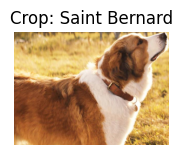

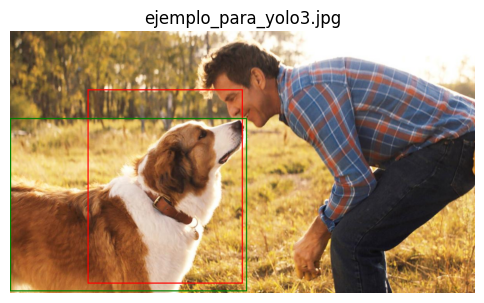


0: 416x640 1 person, 1 car, 1 dog, 163.4ms
Speed: 3.4ms preprocess, 163.4ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 640)
➡️ Pred: 37 (German Sheperd), Real: N/A (N/A), IoU: 0


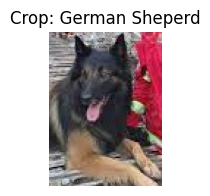

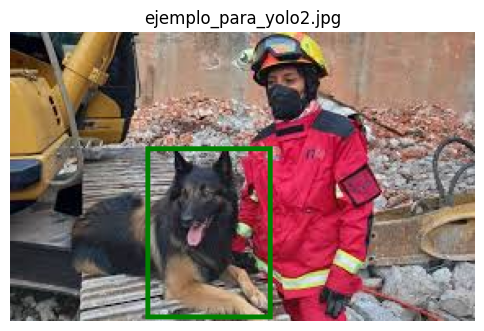


0: 480x640 11 persons, 1 dog, 1 chair, 241.8ms
Speed: 4.8ms preprocess, 241.8ms inference, 8.0ms postprocess per image at shape (1, 3, 480, 640)
➡️ Pred: 38 (Golden Retriever), Real: 38 (Golden Retriever), IoU: 0.07


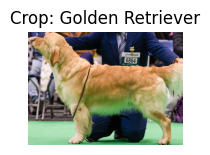

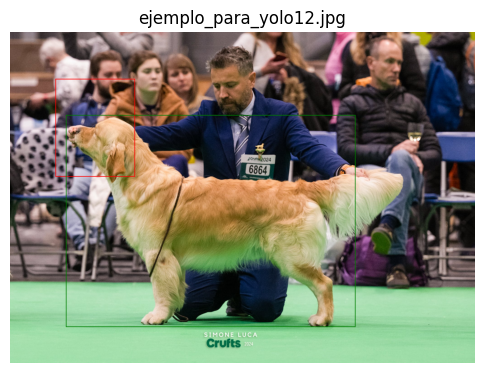


0: 448x640 1 cat, 1 dog, 191.7ms
Speed: 3.8ms preprocess, 191.7ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
➡️ Pred: 38 (Golden Retriever), Real: 38 (Golden Retriever), IoU: 0.04


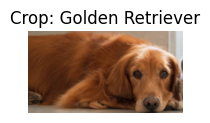

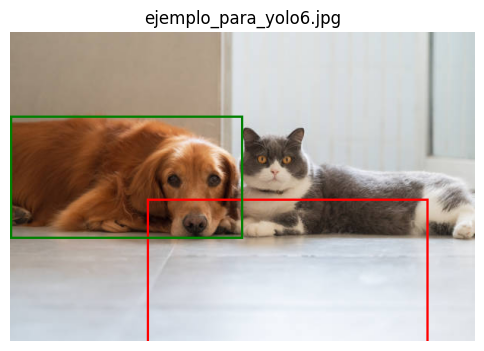


0: 480x640 2 persons, 3 dogs, 161.7ms
Speed: 5.0ms preprocess, 161.7ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
➡️ Pred: 42 (Groenendael), Real: N/A (N/A), IoU: 0


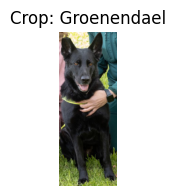

➡️ Pred: 50 (Malinois), Real: 37 (German Sheperd), IoU: 0.27


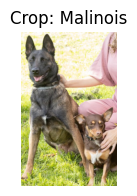

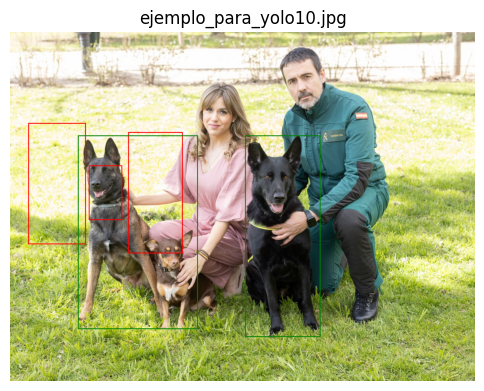


0: 448x640 1 dog, 144.9ms
Speed: 3.6ms preprocess, 144.9ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
➡️ Pred: 49 (Lhasa), Real: N/A (N/A), IoU: 0


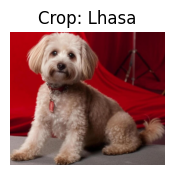

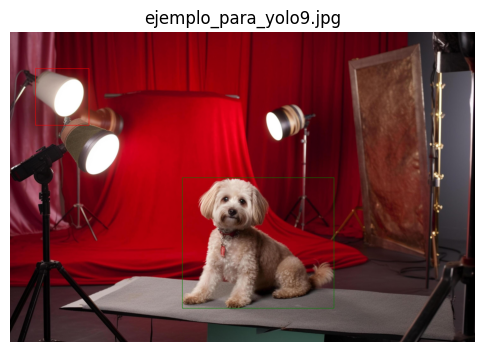


0: 480x640 1 person, 1 dog, 2 cups, 2 apples, 2 teddy bears, 155.9ms
Speed: 5.0ms preprocess, 155.9ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
➡️ Pred: 69 (Yorkie), Real: N/A (N/A), IoU: 0


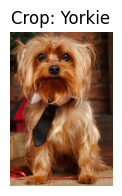

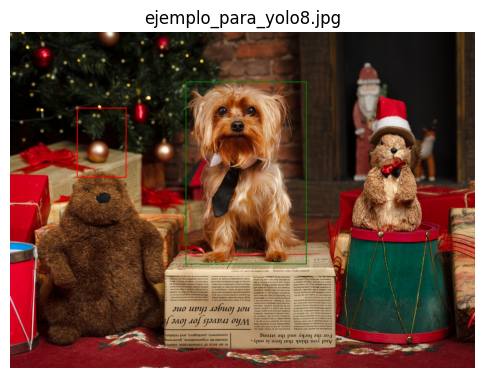


0: 320x640 2 dogs, 151.0ms
Speed: 3.4ms preprocess, 151.0ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 640)
➡️ Pred: 31 (Dalmation), Real: 37 (German Sheperd), IoU: 0.23


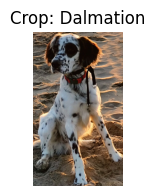

➡️ Pred: 33 (Dingo), Real: N/A (N/A), IoU: 0


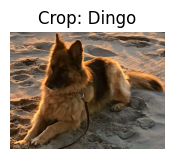

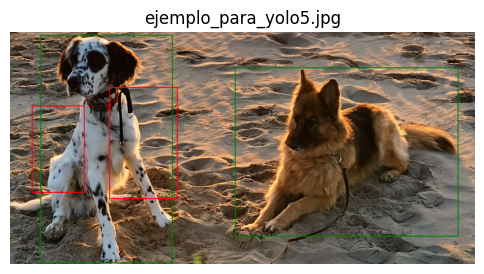


0: 384x640 2 persons, 2 dogs, 237.4ms
Speed: 3.1ms preprocess, 237.4ms inference, 9.9ms postprocess per image at shape (1, 3, 384, 640)
➡️ Pred: 23 (Chinese Crested), Real: N/A (N/A), IoU: 0


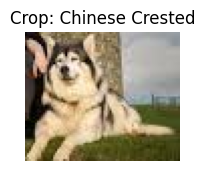

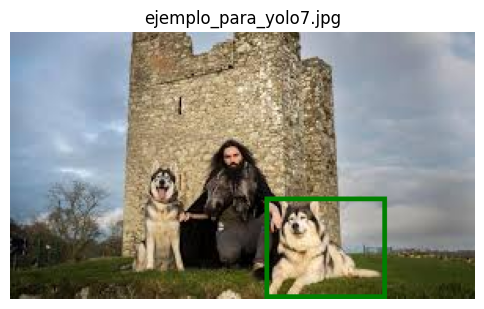

In [ ]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
import time
import os
import json

# Inicialización
y_true = []
y_pred = []
ious = []

t0 = time.time()

conf_threshold = 0.4

for nombre in os.listdir(carpeta_prueba):
    if not nombre.endswith(".jpg"): continue

    ruta_img = os.path.join(carpeta_prueba, nombre)
    ruta_anno = os.path.join(carpeta_anotaciones, nombre.replace(".jpg", ".json"))

    img = Image.open(ruta_img).convert("RGB")
    resultado = detector(img)

    # Filtrar predicciones confiables
    cajas_pred = [box for box in resultado[0].boxes if int(box.cls) == 16 and box.conf.item() > conf_threshold]
    cajas_pred = sorted(cajas_pred, key=lambda b: b.conf.item(), reverse=True)[:2]  # las 2 más confiables

    with open(ruta_anno) as f:
        anotaciones = json.load(f)

    img_draw = img.copy()
    draw = ImageDraw.Draw(img_draw)
    for gt in anotaciones:
        draw.rectangle(gt["bbox"], outline="red", width=3)

    for box in cajas_pred:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        crop = img.crop((x1, y1, x2, y2))
        from PIL import ImageOps

        # --- Padding alrededor del crop ---
        # Podés cambiar el valor 0.1 por 0.2 para más margen
        ancho_crop, alto_crop = crop.size
        padding_x = int(ancho_crop * 0.1)
        padding_y = int(alto_crop * 0.1)

        # Expandir la imagen con padding negro (RGB=(0,0,0))
        crop_con_padding = ImageOps.expand(crop, border=(padding_x, padding_y), fill=(0, 0, 0))

        # Transformar a tensor normalizado como durante entrenamiento
        input_tensor = transform(crop_con_padding).unsqueeze(0).to(device)

        with torch.no_grad():
            output = modelo_resnet18(input_tensor)
            clase_pred = output.argmax(1).item()

        mejor_iou = 0
        mejor_gt = None
        for gt in anotaciones:
            iou = calcular_iou([x1, y1, x2, y2], gt['bbox'])
            if iou > mejor_iou:
                mejor_iou = iou
                mejor_gt = gt

        pred_name = razas_70[clase_pred]
        real_name = mejor_gt['raza']['nombre'] if mejor_gt else "N/A"
        real_idx = mejor_gt['raza']['indice'] if mejor_gt else "N/A"

        print(f"➡️ Pred: {clase_pred} ({pred_name}), Real: {real_idx} ({real_name}), IoU: {round(mejor_iou, 2)}")

        draw.rectangle([x1, y1, x2, y2], outline="green", width=3)

        # Mostrar crop del perro clasificado
        plt.figure(figsize=(2, 2))
        plt.imshow(crop)
        plt.title(f"Crop: {pred_name}")
        plt.axis("off")
        plt.show()

        if mejor_iou >= 0.5:
            y_true.append(real_idx)
            y_pred.append(clase_pred)
            ious.append(mejor_iou)

    # Mostrar imagen final
    plt.figure(figsize=(6, 6))
    plt.imshow(img_draw)
    plt.title(f"{nombre}")
    plt.axis("off")
    plt.show()

## 2. Optimización de Modelos (Elegir una):

In [ ]:
# ----------------------------------
# OPTIMIZACIÓN (opcional): CUANTIZACIÓN
# ----------------------------------

modelo_opt = torch.quantization.quantize_dynamic(
    clasificador, {torch.nn.Linear}, dtype=torch.qint8
)
torch.save(modelo_opt, "modeloA_opt.pt")

## 3. Script de Anotación Automática:

In [ ]:

carpeta_input = "./imagenes_a_anotar"
carpeta_output_txt = "./anotaciones_yolo"
carpeta_output_json = "./anotaciones_coco"

os.makedirs(carpeta_output_txt, exist_ok=True)
os.makedirs(carpeta_output_json, exist_ok=True)

for nombre in os.listdir(carpeta_input):
    if not nombre.endswith(".jpg"): continue
    img = Image.open(os.path.join(carpeta_input, nombre)).convert("RGB")
    w, h = img.size

    resultado = detector(img)
    boxes = [box for box in resultado[0].boxes if int(box.cls) == 16]

    anotaciones_img = []
    with open(os.path.join(carpeta_output_txt, nombre.replace(".jpg", ".txt")), "w") as f:
        for box in boxes:
            x1, y1, x2, y2 = map(float, box.xyxy[0])
            cx = (x1 + x2) / 2 / w
            cy = (y1 + y2) / 2 / h
            bw = (x2 - x1) / w
            bh = (y2 - y1) / h

            crop = img.crop((int(x1), int(y1), int(x2), int(y2)))
            input_tensor = transform(crop).unsqueeze(0)
            with torch.no_grad():
                salida = clasificador(input_tensor)
                clase = salida.argmax(1).item()

            # Formato YOLO
            f.write(f"{clase} {cx:.4f} {cy:.4f} {bw:.4f} {bh:.4f}\n")

            # Para COCO
            anotaciones_img.append({
                "bbox": [x1, y1, x2, y2],
                "categoria": clase,
                "conf": float(box.conf)
            })

    with open(os.path.join(carpeta_output_json, nombre.replace(".jpg", ".json")), "w") as fjson:
        json.dump(anotaciones_img, fjson, indent=2)
